# Cloud Shadow Detection v2

Improvements over `Cloud Shadows Masking-Debug.ipynb`:

1. **Cloud height** — apply DARCLOS safety factor $C = 0.5$; raise pressure-height cap to 16 km; **raise `ValueError`** when neither L1B CTH nor pressure are valid (no silent 15 km fallback).
2. **Polygon shadow** — project the 4 lat/lon corners of every cloud-source pixel and rasterize the shifted quadrilateral (umbra footprint), instead of a 1-pixel Bresenham line.
3. **Quality masking** — exclude $\mathrm{SZA} \geq 75°$, `snow_ice_fraction > 0.5`, set error bits in `processing_quality_flag`, and any non-finite geometry.
4. **Geodetic nearest-pixel** — KDTree on ECEF coordinates of candidate pixel centers (correct at all latitudes; no $\cos(\mathrm{lat})$ bias).
5. **Vectorized projection** — one NumPy call per granule for the full geometry; per-polygon loop only for point-in-polygon.

ACSF (radiometric confirmation) is approximated as the Debug notebook does — `ECF < ECF_SHADOW_THRESH` among PCSF pixels — because the CLDO4 ECF retrieval already encodes the "darker than GLER" signal via its MLER inversion.

In [1]:
import re
import os
import glob
from pathlib import Path

import numpy as np
import netCDF4 as nc
from scipy.spatial import cKDTree
from matplotlib.path import Path as MplPath
import matplotlib.pyplot as plt

import geopandas as gpd
from shapely.geometry import shape
from rasterio.transform import from_bounds
from rasterio.features import shapes

In [2]:
# === Paths ===
L1B_DIR = Path("../data/raw_l1")
L2_DIR  = Path("../data/raw_l2_v3")
VERSION = "V03"
OUTPUT_DIR = Path("../experiments/output_v2")

# === DARCLOS algorithm parameters ===
SAFETY_FACTOR_C   = 0.5        # Trees et al. (2022) Eq. 1
ECF_SOURCE_THRESH = 0.30       # cloud caster threshold (TEMPO NO2 QA convention)
ECF_SHADOW_THRESH = 0.05       # ACSF surrogate via low retrieved ECF
SZA_MAX_DEG       = 75.0       # TEMPO L2 QA convention
H_SCALE_M         = 8500.0     # hypsometric scale height
H_CAP_M           = 16000.0    # max physical cloud altitude (raised from 8 km)
EARTH_RADIUS_M    = 6_378_137.0

# Processing quality flag error bits (CLDO4 V03):
# bit0=geoloc, bit3=psurf_albedo, bit6=scd_neg, bit8=466nm_rad, bit12=ecf_skipped, bit13=ocp_skipped
PQF_ERROR_BITS = 1 | 8 | 64 | 256 | 4096 | 8192     # = 8621

# === Grid ===
# Only xtrack is fixed by the TEMPO instrument; mirror_step varies per granule.
N_XTRACK = 2048

In [3]:
def extract_timestamp_scan(filename):
    m = re.search(r'(\d{8}T\d{6}Z)_S(\d{3})G(\d{2})', filename)
    return (m.group(1), m.group(2), m.group(3)) if m else (None, None, None)

def find_matching_l2_file(l1_file, l2_dir, version="V03"):
    ts, scan, granule = extract_timestamp_scan(l1_file)
    if ts is None:
        return None
    pattern = os.path.join(str(l2_dir), f"TEMPO_CLDO4_L2_{version}_{ts}_S{scan}G*.nc")
    matches = glob.glob(pattern)
    return matches[0] if matches else None

nc_files = sorted(glob.glob(str(L1B_DIR / "*.nc")))
if not nc_files:
    raise FileNotFoundError(f"No L1B .nc files in {L1B_DIR}")

pairs = []
for l1 in nc_files:
    l2 = find_matching_l2_file(l1, L2_DIR, VERSION)
    if l2 is None:
        raise FileNotFoundError(f"No matching L2 {VERSION} for {l1}")
    pairs.append((l1, l2))

print(f"Found {len(pairs)} L1B/L2 pair(s)")

Found 4 L1B/L2 pair(s)


In [4]:
def _load(grp, name, fill=np.nan):
    if name not in grp.variables:
        raise KeyError(f"variable '{name}' missing in group '{grp.path}'")
    return np.ma.filled(grp.variables[name][:].astype(np.float64), fill)


def _check_shape(arr, expected, name):
    if arr.shape != expected:
        raise ValueError(f"{name} has shape {arr.shape}, expected {expected}")


def load_granule(l1b_path: Path, l2_path: Path) -> dict:
    """Load all DARCLOS-TEMPO inputs from one L1B + L2 pair.

    The mirror_step dimension varies per granule; only xtrack = N_XTRACK is fixed.
    Returns `data["shape2d"] = (n_mirror_steps, N_XTRACK)` for downstream sizing.
    """
    data = {}

    with nc.Dataset(str(l2_path)) as l2:
        geo, prod, supp = l2["geolocation"], l2["product"], l2["support_data"]
        data["lat"]               = _load(geo,  "latitude")
        data["lon"]               = _load(geo,  "longitude")
        data["lat_bounds"]        = _load(geo,  "latitude_bounds")
        data["lon_bounds"]        = _load(geo,  "longitude_bounds")
        data["cloud_fraction"]    = _load(prod, "cloud_fraction")
        data["cloud_pressure"]    = _load(prod, "cloud_pressure")
        data["pqf"]               = _load(prod, "processing_quality_flag", fill=9999.0)
        data["terrain_height"]    = _load(supp, "terrain_height")
        data["surface_pressure"]  = _load(supp, "surface_pressure")
        data["snow_ice_fraction"] = _load(supp, "snow_ice_fraction")

    # Derive expected 2D shape from the first array; assert xtrack is the fixed dimension.
    n_mirror_steps, n_xtrack = data["lat"].shape
    if n_xtrack != N_XTRACK:
        raise ValueError(
            f"xtrack dimension {n_xtrack} != fixed N_XTRACK = {N_XTRACK}. "
            f"This granule does not match the TEMPO instrument xtrack count."
        )
    e2d = (n_mirror_steps, N_XTRACK)
    e3d = (n_mirror_steps, N_XTRACK, 4)
    data["shape2d"] = e2d

    with nc.Dataset(str(l1b_path)) as l1b:
        band = l1b["band_290_490_nm"]
        cmg  = l1b["cloud_mask_group"]
        data["sza"] = _load(band, "solar_zenith_angle")
        data["saa"] = _load(band, "solar_azimuth_angle")
        data["vza"] = _load(band, "viewing_zenith_angle")
        data["vaa"] = _load(band, "viewing_azimuth_angle")
        data["cth_l1b"] = _load(band, "cloud_top_height")
        data["red"]   = _load(cmg, "red")
        data["green"] = _load(cmg, "green")
        data["blue"]  = _load(cmg, "blue")

    for k in ["lat","lon","cloud_fraction","cloud_pressure","pqf",
              "terrain_height","surface_pressure","snow_ice_fraction",
              "sza","saa","vza","vaa","cth_l1b","red","green","blue"]:
        _check_shape(data[k], e2d, k)
    _check_shape(data["lat_bounds"], e3d, "lat_bounds")
    _check_shape(data["lon_bounds"], e3d, "lon_bounds")
    return data

## Improvement 5 — Explicit quality masking

In [5]:
def build_quality_mask(data: dict) -> np.ndarray:
    pqf_int  = data["pqf"].astype(np.int64)
    no_error = (pqf_int & PQF_ERROR_BITS) == 0
    mask = (
        (data["sza"] < SZA_MAX_DEG)
        & (data["snow_ice_fraction"] <= 0.5)
        & no_error
        & np.isfinite(data["lat"]) & np.isfinite(data["lon"])
        & np.isfinite(data["sza"]) & np.isfinite(data["saa"])
        & np.isfinite(data["vza"]) & np.isfinite(data["vaa"])
    )
    assert mask.shape == data["shape2d"]
    return mask

## Improvement 2 — Cloud height handling

Priority: L1B `cloud_top_height` (ASL) → pressure-based `H_SCALE · ln(p_sfc/p_cloud) + terrain` (ASL). Cap physical altitude at 16 km. Effective shadow height = `(1 + C) · (h_cloud_ASL − h_terrain)`. **Raise `ValueError`** if any source pixel ends up without a finite height (no silent 15 km invention).

In [6]:
# Maximum fraction of source pixels allowed to be dropped for missing height.
# Above this fraction the granule is treated as broken and ValueError is raised.
MAX_DROP_FRAC = 0.02


def compute_cloud_height(data: dict, source_mask: np.ndarray):
    """Return (h_eff, height_valid).

    - h_eff        : (132, 2048) float, effective shadow-projection height
                     above terrain (m). NaN where neither L1B CTH nor the
                     pressure-based fallback yields a physical value.
    - height_valid : (132, 2048) bool, True where h_eff is finite and > 0.

    Pixels in `source_mask` with no valid height are reported by count and
    excluded from downstream projection by the caller. If the dropped fraction
    exceeds MAX_DROP_FRAC, raises ValueError.
    """
    cth   = data["cth_l1b"]
    p_cld = data["cloud_pressure"]
    p_sfc = data["surface_pressure"]
    h_sfc = data["terrain_height"]

    h_asl = np.where(np.isfinite(cth) & (cth > h_sfc), cth, np.nan)

    with np.errstate(invalid="ignore", divide="ignore"):
        h_above = H_SCALE_M * np.log(p_sfc / p_cld)
    h_press_asl = np.where(
        np.isfinite(h_above) & (h_above > 0) & np.isfinite(h_sfc),
        h_above + h_sfc,
        np.nan,
    )

    h_combined = np.where(np.isnan(h_asl), h_press_asl, h_asl)
    h_combined = np.clip(h_combined, h_sfc + 1.0, H_CAP_M)

    h_eff = (1.0 + SAFETY_FACTOR_C) * (h_combined - h_sfc)
    h_eff = np.where(np.isfinite(h_eff) & (h_eff > 0), h_eff, np.nan)
    height_valid = np.isfinite(h_eff)

    n_src  = int(source_mask.sum())
    n_drop = int((source_mask & ~height_valid).sum())
    frac   = n_drop / max(n_src, 1)
    if n_drop > 0:
        print(
            f"  [height] dropping {n_drop}/{n_src} source pixels ({frac:.2%}) "
            f"with cloud_pressure >= surface_pressure or non-finite inputs"
        )
    if frac > MAX_DROP_FRAC:
        raise ValueError(
            f"{n_drop}/{n_src} ({frac:.1%}) source pixels lack a valid height — "
            f"exceeds MAX_DROP_FRAC = {MAX_DROP_FRAC:.1%}. Granule likely broken."
        )
    return h_eff, height_valid

## Improvements 3, 4, 7 — Vectorized polygon projection + KDTree rasterization

In [7]:
def latlon_to_ecef(lat_deg: np.ndarray, lon_deg: np.ndarray) -> np.ndarray:
    lat_r = np.radians(lat_deg)
    lon_r = np.radians(lon_deg)
    R = EARTH_RADIUS_M
    x = R * np.cos(lat_r) * np.cos(lon_r)
    y = R * np.cos(lat_r) * np.sin(lon_r)
    z = R * np.sin(lat_r)
    return np.stack([x, y, z], axis=-1)


def project_shadow_polygons(data: dict, h_eff: np.ndarray, source_ij: np.ndarray):
    """Vectorized shadow-corner projection (Trees et al. 2022, Eqs. 2-7).

    Returns (N_source, 4) arrays of shifted corner lats and lons.
    """
    ii, jj = source_ij[:, 0], source_ij[:, 1]
    sza = np.radians(data["sza"][ii, jj])
    saa = np.radians(data["saa"][ii, jj])
    vza = np.radians(data["vza"][ii, jj])
    vaa = np.radians(data["vaa"][ii, jj])
    h_km = h_eff[ii, jj] / 1000.0

    dx_km = h_km * (np.tan(vza) * np.sin(vaa) - np.tan(sza) * np.sin(saa))
    dy_km = h_km * (np.tan(vza) * np.cos(vaa) - np.tan(sza) * np.cos(saa))

    cos_lat_c = np.cos(np.radians(data["lat"][ii, jj]))
    d_lat = dy_km / 111.32
    d_lon = dx_km / (111.32 * cos_lat_c)

    shadow_lats = data["lat_bounds"][ii, jj, :] + d_lat[:, None]
    shadow_lons = data["lon_bounds"][ii, jj, :] + d_lon[:, None]
    return shadow_lats, shadow_lons


def compute_pcsf_acsf(data: dict, quality_mask: np.ndarray):
    cf = data["cloud_fraction"]
    source_mask    = (cf >= ECF_SOURCE_THRESH) & quality_mask
    candidate_mask = (cf <  ECF_SOURCE_THRESH) & quality_mask

    h_eff, height_valid = compute_cloud_height(data, source_mask)
    source_mask = source_mask & height_valid

    source_ij = np.argwhere(source_mask)
    print(f"  {len(source_ij)} source pixels, {int(candidate_mask.sum())} candidate pixels")

    cand_ij  = np.argwhere(candidate_mask)
    cand_lat = data["lat"][candidate_mask]
    cand_lon = data["lon"][candidate_mask]
    cand_xyz = latlon_to_ecef(cand_lat, cand_lon)
    tree = cKDTree(cand_xyz)

    s_lats, s_lons = project_shadow_polygons(data, h_eff, source_ij)

    pcsf = np.zeros(data["shape2d"], dtype=bool)
    n_src = len(source_ij)
    for k in range(n_src):
        if k > 0 and k % 20000 == 0:
            print(f"    {k}/{n_src} ({100*k/n_src:.0f}%)")
        plat = s_lats[k]
        plon = s_lons[k]
        if not (np.all(np.isfinite(plat)) and np.all(np.isfinite(plon))):
            continue

        c_lat = float(plat.mean())
        c_lon = float(plon.mean())
        c_xyz = latlon_to_ecef(np.array([c_lat]), np.array([c_lon]))[0]
        corners_xyz = latlon_to_ecef(plat, plon)
        radius = float(np.linalg.norm(corners_xyz - c_xyz, axis=1).max()) * 1.5

        ids = tree.query_ball_point(c_xyz, radius)
        if not ids:
            continue
        ids = np.asarray(ids, dtype=np.int64)

        poly = MplPath(np.column_stack([plon, plat]))
        inside = poly.contains_points(
            np.column_stack([cand_lon[ids], cand_lat[ids]])
        )
        if not np.any(inside):
            continue
        hits = cand_ij[ids[inside]]
        pcsf[hits[:, 0], hits[:, 1]] = True

    acsf = pcsf & (cf < ECF_SHADOW_THRESH) & quality_mask
    assert int(acsf.sum()) <= int(pcsf.sum())
    return pcsf, acsf, source_mask

In [8]:
def prepare_rgb(data: dict, apply_gamma: bool = True) -> np.ndarray:
    r = np.clip(data["red"],   0.0, 1.0)
    g = np.clip(data["green"], 0.0, 1.0)
    b = np.clip(data["blue"],  0.0, 1.0)
    if apply_gamma:
        r, g, b = r**0.4, g**0.4, b**0.4
    rgb = np.stack([r, g, b], axis=-1)
    rgb = np.nan_to_num(rgb, nan=0.0)
    return np.flip(np.transpose(rgb, (1, 0, 2)), axis=0)


def plot_granule(data, source_mask, pcsf, acsf, title, save_path: Path | None = None):
    rgb = prepare_rgb(data)
    src_v  = np.flip(np.transpose(source_mask, (1, 0)), axis=0)
    pcsf_v = np.flip(np.transpose(pcsf,        (1, 0)), axis=0)
    acsf_v = np.flip(np.transpose(acsf,        (1, 0)), axis=0)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(rgb)
    axes[0].set_title("TEMPO RGB"); axes[0].axis("off")

    axes[1].imshow(rgb * 0.6)
    axes[1].imshow(np.where(src_v, 1.0, np.nan), cmap="autumn", alpha=0.7,
                   vmin=0, vmax=1)
    axes[1].set_title(f"Cloud sources ({int(source_mask.sum())} px)")
    axes[1].axis("off")

    axes[2].imshow(rgb * 0.6)
    axes[2].imshow(np.where(pcsf_v, 1.0, np.nan), cmap="Oranges", alpha=0.55,
                   vmin=0, vmax=1)
    axes[2].imshow(np.where(acsf_v, 1.0, np.nan), cmap="Reds", alpha=0.85,
                   vmin=0, vmax=1)
    axes[2].set_title(f"PCSF: {int(pcsf.sum())} px | ACSF: {int(acsf.sum())} px")
    axes[2].axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"  figure -> {save_path}")
    plt.show()


def save_masks(out_path: Path, data: dict, source_mask, pcsf, acsf, quality_mask) -> None:
    """Persist masks + geolocation as a compressed .npz alongside the figure."""
    np.savez_compressed(
        out_path,
        source_mask=source_mask.astype(np.uint8),
        pcsf=pcsf.astype(np.uint8),
        acsf=acsf.astype(np.uint8),
        quality_mask=quality_mask.astype(np.uint8),
        cloud_fraction=data["cloud_fraction"].astype(np.float32),
        lat=data["lat"].astype(np.float32),
        lon=data["lon"].astype(np.float32),
    )
    print(f"  masks  -> {out_path}")

In [9]:
def _mask_to_shapefile(
    mask_oriented: np.ndarray,
    transform,
    mask_type: str,
    mask_name: str,
    source_file: str,
    out_path: Path,
) -> Path | None:
    """Polygonize a boolean raster mask and write as a shapefile (EPSG:4326)."""
    mask_int = mask_oriented.astype(np.int32)
    results = list(shapes(mask_int, mask=(mask_int == 1), transform=transform))
    if not results:
        print(f"    {mask_name}: no features")
        return None

    geometries = [shape(geom) for geom, _ in results]
    properties = [
        {"type": mask_type, "name": mask_name, "value": int(v), "source": source_file}
        for _, v in results
    ]
    gdf = gpd.GeoDataFrame(properties, geometry=geometries, crs="EPSG:4326")
    gdf["area_deg2"] = gdf.geometry.area
    gdf.to_file(out_path)
    print(f"    {mask_name}: {len(gdf)} polygon(s) -> {out_path.name}")
    return out_path


def save_shapefiles(
    out_prefix: Path,
    data: dict,
    source_mask: np.ndarray,
    pcsf: np.ndarray,
    acsf: np.ndarray,
    source_file: str,
) -> dict:
    """Export source/PCSF/ACSF masks as shapefiles.

    Same orientation convention as the Debug notebook: transpose + flip so that
    the polygon raster aligns with the RGB composite, then use a regular-grid
    affine transform derived from the lat/lon bounding box.

    Note: TEMPO's swath grid is not exactly rectilinear in lat/lon, so the
    bounding-box transform introduces geometric distortion near granule edges.
    This matches the Debug notebook's behavior for consistency.
    """
    lat = data["lat"]
    lon = data["lon"]

    src_o  = np.flip(np.transpose(source_mask, (1, 0)), axis=0)
    pcsf_o = np.flip(np.transpose(pcsf,        (1, 0)), axis=0)
    acsf_o = np.flip(np.transpose(acsf,        (1, 0)), axis=0)
    lon_o  = np.flip(np.transpose(lon, (1, 0)), axis=0)
    lat_o  = np.flip(np.transpose(lat, (1, 0)), axis=0)

    height, width = src_o.shape
    west  = float(np.nanmin(lon_o))
    east  = float(np.nanmax(lon_o))
    south = float(np.nanmin(lat_o))
    north = float(np.nanmax(lat_o))
    if not all(np.isfinite([west, east, south, north])):
        raise ValueError("Non-finite lat/lon bounds — cannot build affine transform.")

    transform = from_bounds(west, south, east, north, width, height)
    print(f"  extent: [{west:.2f}, {south:.2f}, {east:.2f}, {north:.2f}]")

    paths = {}
    for arr, mtype, mname, suffix in [
        (src_o,  "cloud_source",     "Cloud source",   "clouds"),
        (pcsf_o, "potential_shadow", "Potential shadow (PCSF)", "potential_shadows"),
        (acsf_o, "actual_shadow",    "Actual shadow (ACSF)",    "actual_shadows"),
    ]:
        p = _mask_to_shapefile(
            arr, transform, mtype, mname, source_file,
            Path(f"{out_prefix}_{suffix}.shp"),
        )
        if p is not None:
            paths[suffix] = p
    return paths


=== TEMPO_RAD_L1_V04_20250909T115202Z_S002G02.nc ===
  quality-valid pixels: 230838 / 270336 (85.4%)
  [height] dropping 13/106540 source pixels (0.01%) with cloud_pressure >= surface_pressure or non-finite inputs
  106527 source pixels, 124298 candidate pixels
    20000/106527 (19%)
    40000/106527 (38%)
    60000/106527 (56%)
    80000/106527 (75%)
    100000/106527 (94%)
  PCSF:  15418    ACSF:   1833
  figure -> ../experiments/output_v2/TEMPO_RAD_L1_V04_20250909T115202Z_S002G02_v2.png


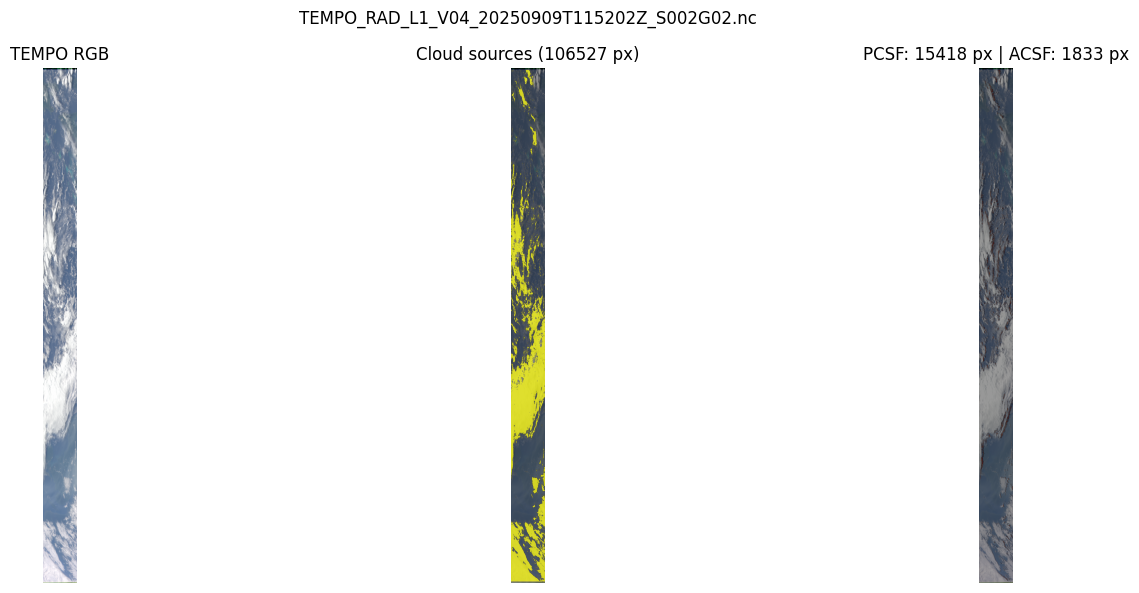

  masks  -> ../experiments/output_v2/TEMPO_RAD_L1_V04_20250909T115202Z_S002G02_v2.npz
  shapefiles:
  extent: [-77.87, 17.26, -45.97, 60.57]
    Cloud source: 1586 polygon(s) -> TEMPO_RAD_L1_V04_20250909T115202Z_S002G02_clouds.shp
    Potential shadow (PCSF): 4634 polygon(s) -> TEMPO_RAD_L1_V04_20250909T115202Z_S002G02_potential_shadows.shp


/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_1281/3133854318.py:22: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf["area_deg2"] = gdf.geometry.area
/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_1281/3133854318.py:22: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf["area_deg2"] = gdf.geometry.area
/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_1281/3133854318.py:22: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf["area_deg2"] = gdf.geometry.area


    Actual shadow (ACSF): 892 polygon(s) -> TEMPO_RAD_L1_V04_20250909T115202Z_S002G02_actual_shadows.shp

=== TEMPO_RAD_L1_V04_20250909T115842Z_S002G03.nc ===
  quality-valid pixels: 38290 / 268288 (14.3%)
  25833 source pixels, 12457 candidate pixels
    20000/25833 (77%)
  PCSF:   1845    ACSF:      1
  figure -> ../experiments/output_v2/TEMPO_RAD_L1_V04_20250909T115842Z_S002G03_v2.png


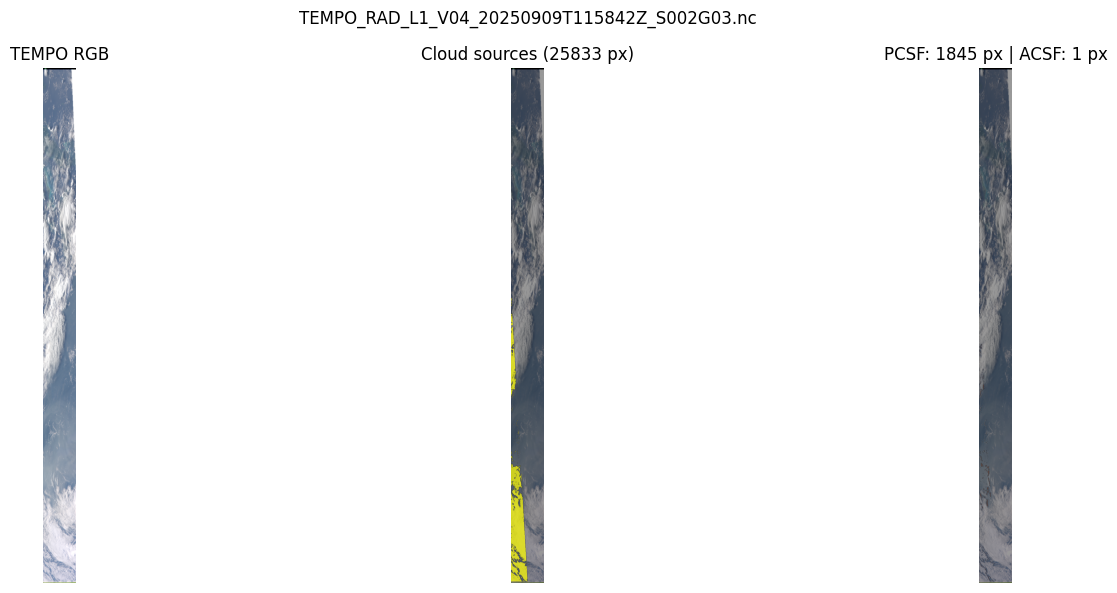

  masks  -> ../experiments/output_v2/TEMPO_RAD_L1_V04_20250909T115842Z_S002G03_v2.npz
  shapefiles:
  extent: [-83.76, 17.21, -64.04, 58.71]
    Cloud source: 139 polygon(s) -> TEMPO_RAD_L1_V04_20250909T115842Z_S002G03_clouds.shp
    Potential shadow (PCSF): 605 polygon(s) -> TEMPO_RAD_L1_V04_20250909T115842Z_S002G03_potential_shadows.shp
    Actual shadow (ACSF): 1 polygon(s) -> TEMPO_RAD_L1_V04_20250909T115842Z_S002G03_actual_shadows.shp

=== TEMPO_RAD_L1_V04_20250909T125205Z_S003G05.nc ===
  quality-valid pixels: 2742 / 268288 (1.0%)
  [height] dropping 82/1086 source pixels (7.55%) with cloud_pressure >= surface_pressure or non-finite inputs


/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_1281/3133854318.py:22: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf["area_deg2"] = gdf.geometry.area
/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_1281/3133854318.py:22: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf["area_deg2"] = gdf.geometry.area
/var/folders/0j/71sn2s2j71l6q088k8_ppzsc0000gn/T/ipykernel_1281/3133854318.py:22: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf["area_deg2"] = gdf.geometry.area


ValueError: 82/1086 (7.6%) source pixels lack a valid height — exceeds MAX_DROP_FRAC = 2.0%. Granule likely broken.

In [10]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

results = []
for l1b_path, l2_path in pairs:
    name = os.path.basename(l1b_path)
    stem = os.path.splitext(name)[0]
    print(f"\n=== {name} ===")
    data  = load_granule(Path(l1b_path), Path(l2_path))
    qmask = build_quality_mask(data)
    print(f"  quality-valid pixels: {int(qmask.sum())} / {qmask.size} ({qmask.mean():.1%})")
    pcsf, acsf, source_mask = compute_pcsf_acsf(data, qmask)
    print(f"  PCSF: {int(pcsf.sum()):6d}    ACSF: {int(acsf.sum()):6d}")

    fig_path  = OUTPUT_DIR / f"{stem}_v2.png"
    mask_path = OUTPUT_DIR / f"{stem}_v2.npz"
    plot_granule(data, source_mask, pcsf, acsf, title=name, save_path=fig_path)
    save_masks(mask_path, data, source_mask, pcsf, acsf, qmask)

    print("  shapefiles:")
    shp_prefix = OUTPUT_DIR / stem
    shp_paths = save_shapefiles(shp_prefix, data, source_mask, pcsf, acsf, name)

    results.append({
        "file": name,
        "n_source": int(source_mask.sum()),
        "n_pcsf":   int(pcsf.sum()),
        "n_acsf":   int(acsf.sum()),
        "shapefiles": list(shp_paths.keys()),
    })

print("\nSummary:")
for r in results:
    print(f"  {r['file']:60s} src={r['n_source']:6d} pcsf={r['n_pcsf']:6d} acsf={r['n_acsf']:6d}")